ReLU

学習を開始します...


Epoch 500: Total Loss 3.699474e-03 | LR 0.005000
Epoch 1000: Total Loss 3.189770e-03 | LR 0.005000
Epoch 1500: Total Loss 2.827788e-03 | LR 0.002500
Epoch 2000: Total Loss 2.715936e-03 | LR 0.000078
Epoch 2500: Total Loss 2.709302e-03 | LR 0.000002
Epoch 3000: Total Loss 2.709222e-03 | LR 0.000000
Epoch 3500: Total Loss 2.709143e-03 | LR 0.000000
Epoch 4000: Total Loss 2.709127e-03 | LR 0.000000
Epoch 4500: Total Loss 2.709104e-03 | LR 0.000000
Epoch 5000: Total Loss 2.709074e-03 | LR 0.000000
訓練が完了しました。
Max Relative Error: 0.029125


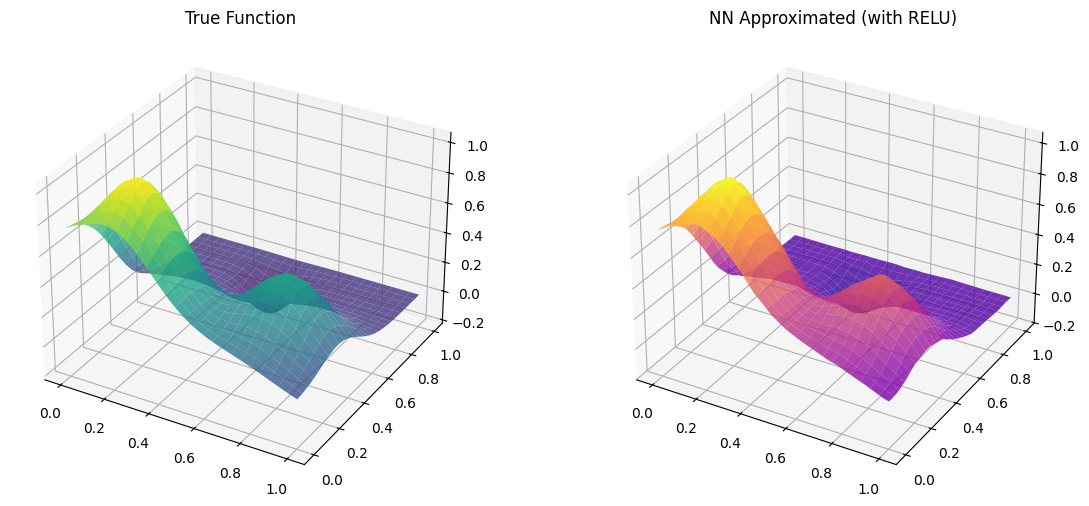

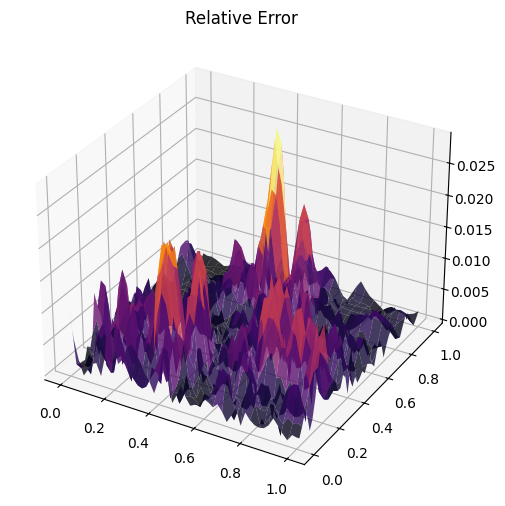

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義（ベース共通化）
def franke_base(x, y, xp):
    term1 = 0.75 * xp.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * xp.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * xp.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * xp.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

def franke_function(x, y):
    return franke_base(x, y, np)

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)

# 【変更点】入力に requires_grad=True を指定し、ラベルは torch の数式でグラフを繋げて計算
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32, requires_grad=True)
labels = franke_base(features[:, 0], features[:, 1], torch).view(-1, 1)

# 【追加】真の勾配を計算し、.detach() で定数化（計算グラフを切り離す）
true_grad = torch.autograd.grad(
    outputs=labels, inputs=features, grad_outputs=torch.ones_like(labels), create_graph=False
)[0].detach()

# ラベル自体も定数化
labels = labels.detach()

# 3. モデル定義 (指定の tanh 4層モデル)
class ReLU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = ReLU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
lambda_grad = 0.1  # 勾配正則化の係数

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss_val = criterion(pred, labels)
    
    # 【追加】予測値の勾配計算
    pred_grad = torch.autograd.grad(
        outputs=pred, inputs=features, grad_outputs=torch.ones_like(pred), create_graph=True
    )[0]
    loss_grad = criterion(pred_grad, true_grad)
    
    # 合計損失
    total_loss = loss_val + lambda_grad * loss_grad
    total_loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(total_loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Total Loss {total_loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with RELU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

tanh

学習を開始します...
Epoch 500: Total Loss 4.560865e-04 | LR 0.005000
Epoch 1000: Total Loss 5.291429e-05 | LR 0.005000
Epoch 1500: Total Loss 2.053882e-05 | LR 0.005000
Epoch 2000: Total Loss 1.428748e-05 | LR 0.002500
Epoch 2500: Total Loss 1.025510e-05 | LR 0.002500
Epoch 3000: Total Loss 7.399127e-06 | LR 0.002500
Epoch 3500: Total Loss 5.873897e-06 | LR 0.001250
Epoch 4000: Total Loss 4.922483e-06 | LR 0.001250
Epoch 4500: Total Loss 4.089707e-06 | LR 0.001250
Epoch 5000: Total Loss 3.549389e-06 | LR 0.000625
訓練が完了しました。
Max Relative Error: 0.000982


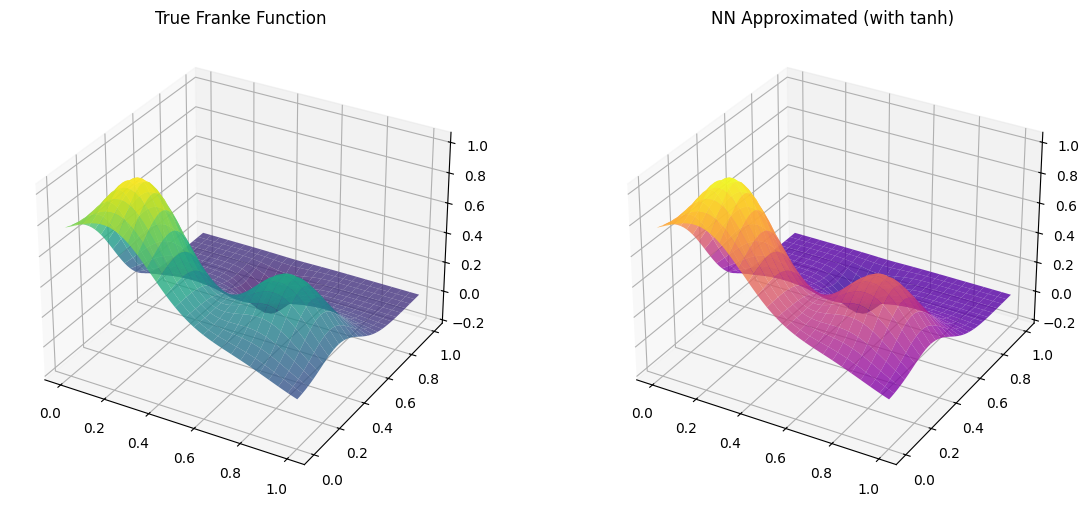

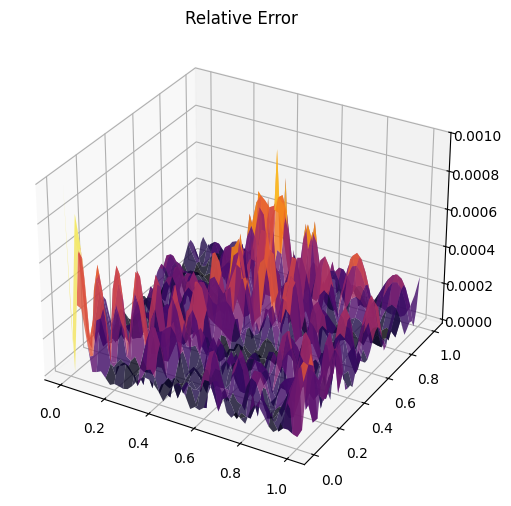

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義（ベース共通化）
def franke_base(x, y, xp):
    term1 = 0.75 * xp.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * xp.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * xp.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * xp.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

def franke_function(x, y):
    return franke_base(x, y, np)

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)

# 【変更点】入力に requires_grad=True を指定し、ラベルは torch の数式でグラフを繋げて計算
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32, requires_grad=True)
labels = franke_base(features[:, 0], features[:, 1], torch).view(-1, 1)

# 【追加】真の勾配を計算し、.detach() で定数化（計算グラフを切り離す）
true_grad = torch.autograd.grad(
    outputs=labels, inputs=features, grad_outputs=torch.ones_like(labels), create_graph=False
)[0].detach()

# ラベル自体も定数化
labels = labels.detach()

# 3. モデル定義 (指定の tanh 4層モデル)
class Tanh_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = Tanh_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
lambda_grad = 0.1  # 勾配正則化の係数

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss_val = criterion(pred, labels)
    
    # 【追加】予測値の勾配計算
    pred_grad = torch.autograd.grad(
        outputs=pred, inputs=features, grad_outputs=torch.ones_like(pred), create_graph=True
    )[0]
    loss_grad = criterion(pred_grad, true_grad)
    
    # 合計損失
    total_loss = loss_val + lambda_grad * loss_grad
    total_loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(total_loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Total Loss {total_loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Franke Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with tanh)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

SiLU

学習を開始します...
Epoch 500: Total Loss 1.880559e-04 | LR 0.005000
Epoch 1000: Total Loss 2.524372e-05 | LR 0.005000
Epoch 1500: Total Loss 1.133664e-05 | LR 0.005000
Epoch 2000: Total Loss 5.950954e-06 | LR 0.005000
Epoch 2500: Total Loss 3.697664e-06 | LR 0.005000
Epoch 3000: Total Loss 2.571341e-06 | LR 0.005000
Epoch 3500: Total Loss 2.073157e-06 | LR 0.002500
Epoch 4000: Total Loss 1.685775e-06 | LR 0.002500
Epoch 4500: Total Loss 1.382494e-06 | LR 0.002500
Epoch 5000: Total Loss 1.243348e-06 | LR 0.001250
訓練が完了しました。
Max Relative Error: 0.000722


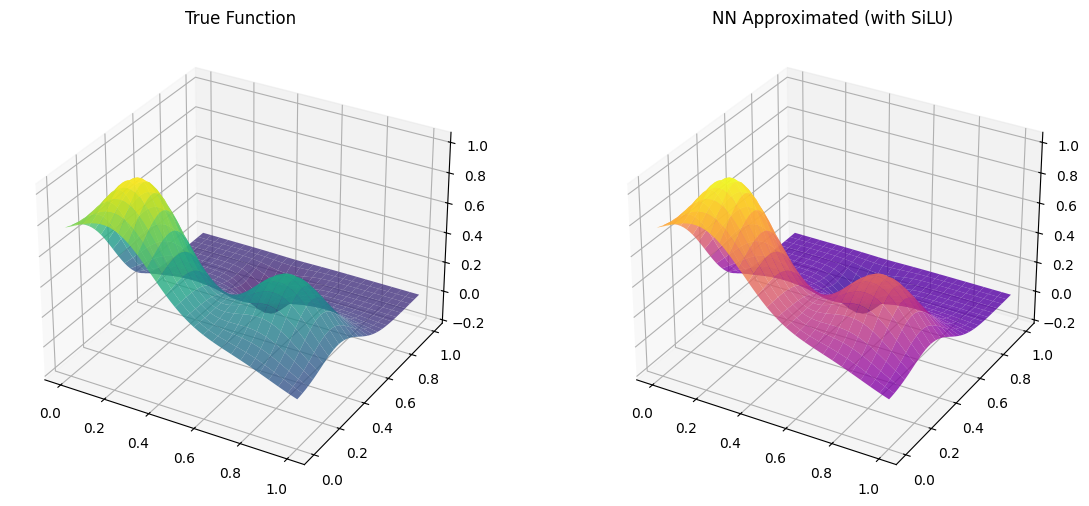

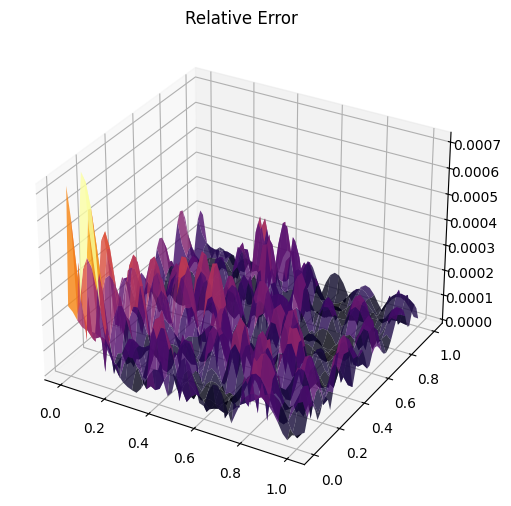

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義（ベース共通化）
def franke_base(x, y, xp):
    term1 = 0.75 * xp.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * xp.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * xp.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * xp.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

def franke_function(x, y):
    return franke_base(x, y, np)

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)

# 【変更点】入力に requires_grad=True を指定し、ラベルは torch の数式でグラフを繋げて計算
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32, requires_grad=True)
labels = franke_base(features[:, 0], features[:, 1], torch).view(-1, 1)

# 【追加】真の勾配を計算し、.detach() で定数化（計算グラフを切り離す）
true_grad = torch.autograd.grad(
    outputs=labels, inputs=features, grad_outputs=torch.ones_like(labels), create_graph=False
)[0].detach()

# ラベル自体も定数化
labels = labels.detach()

# 3. モデル定義 (指定の silu 4層モデル)
class SiLU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = SiLU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
lambda_grad = 0.1  # 勾配正則化の係数

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss_val = criterion(pred, labels)
    
    # 【追加】予測値の勾配計算
    pred_grad = torch.autograd.grad(
        outputs=pred, inputs=features, grad_outputs=torch.ones_like(pred), create_graph=True
    )[0]
    loss_grad = criterion(pred_grad, true_grad)
    
    # 合計損失
    total_loss = loss_val + lambda_grad * loss_grad
    total_loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(total_loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Total Loss {total_loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with SiLU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

GELU

学習を開始します...
Epoch 500: Total Loss 3.584215e-05 | LR 0.005000
Epoch 1000: Total Loss 5.288903e-06 | LR 0.005000
Epoch 1500: Total Loss 6.471908e-06 | LR 0.005000
Epoch 2000: Total Loss 2.144620e-06 | LR 0.002500
Epoch 2500: Total Loss 1.557493e-06 | LR 0.002500
Epoch 3000: Total Loss 3.556826e-06 | LR 0.002500
Epoch 3500: Total Loss 1.014185e-06 | LR 0.001250
Epoch 4000: Total Loss 8.735319e-07 | LR 0.001250
Epoch 4500: Total Loss 7.519353e-07 | LR 0.001250
Epoch 5000: Total Loss 6.957105e-07 | LR 0.000625
訓練が完了しました。
Max Relative Error: 0.000412


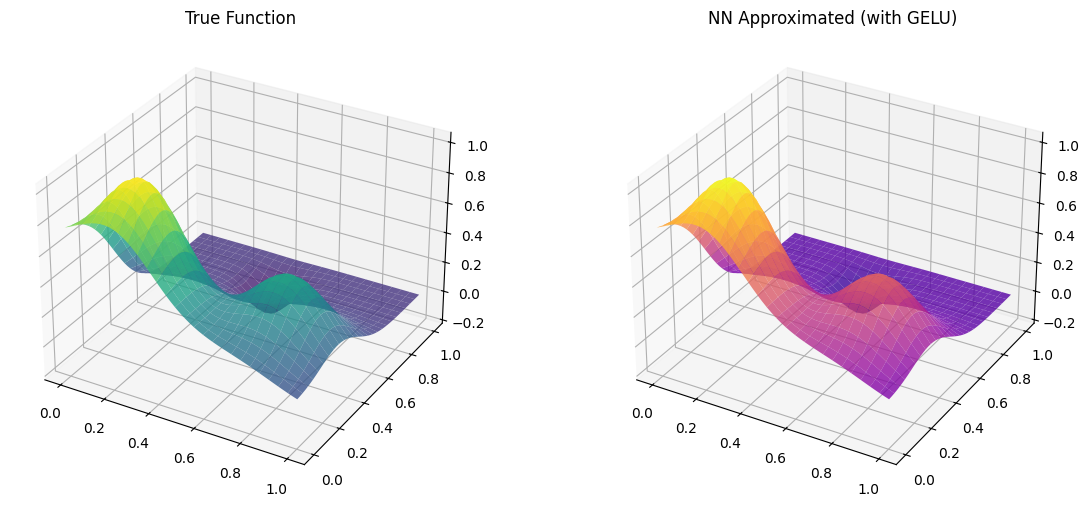

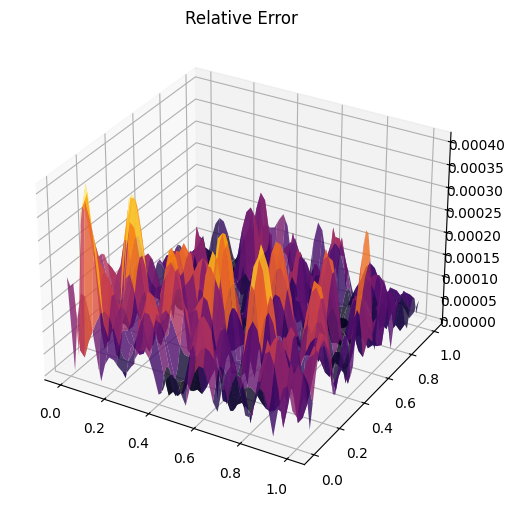

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義（ベース共通化）
def franke_base(x, y, xp):
    term1 = 0.75 * xp.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * xp.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * xp.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * xp.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

def franke_function(x, y):
    return franke_base(x, y, np)

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)

# 【変更点】入力に requires_grad=True を指定し、ラベルは torch の数式でグラフを繋げて計算
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32, requires_grad=True)
labels = franke_base(features[:, 0], features[:, 1], torch).view(-1, 1)

# 【追加】真の勾配を計算し、.detach() で定数化（計算グラフを切り離す）
true_grad = torch.autograd.grad(
    outputs=labels, inputs=features, grad_outputs=torch.ones_like(labels), create_graph=False
)[0].detach()

# ラベル自体も定数化
labels = labels.detach()

# 3. モデル定義 (指定の silu 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
lambda_grad = 0.1  # 勾配正則化の係数

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss_val = criterion(pred, labels)
    
    # 【追加】予測値の勾配計算
    pred_grad = torch.autograd.grad(
        outputs=pred, inputs=features, grad_outputs=torch.ones_like(pred), create_graph=True
    )[0]
    loss_grad = criterion(pred_grad, true_grad)
    
    # 合計損失
    total_loss = loss_val + lambda_grad * loss_grad
    total_loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(total_loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Total Loss {total_loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with GELU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

学習を開始します...
Epoch 500: Total Loss 1.696955e-04 | LR 0.005000
Epoch 1000: Total Loss 3.346217e-05 | LR 0.005000
Epoch 1500: Total Loss 2.422773e-05 | LR 0.005000
Epoch 2000: Total Loss 1.231401e-05 | LR 0.005000
Epoch 2500: Total Loss 7.845892e-06 | LR 0.002500
Epoch 3000: Total Loss 5.940683e-06 | LR 0.002500
Epoch 3500: Total Loss 4.584244e-06 | LR 0.002500
Epoch 4000: Total Loss 2.875585e-05 | LR 0.002500
Epoch 4500: Total Loss 3.107993e-06 | LR 0.001250
Epoch 5000: Total Loss 2.723219e-06 | LR 0.001250
訓練が完了しました。
Max Relative Error: 0.000811


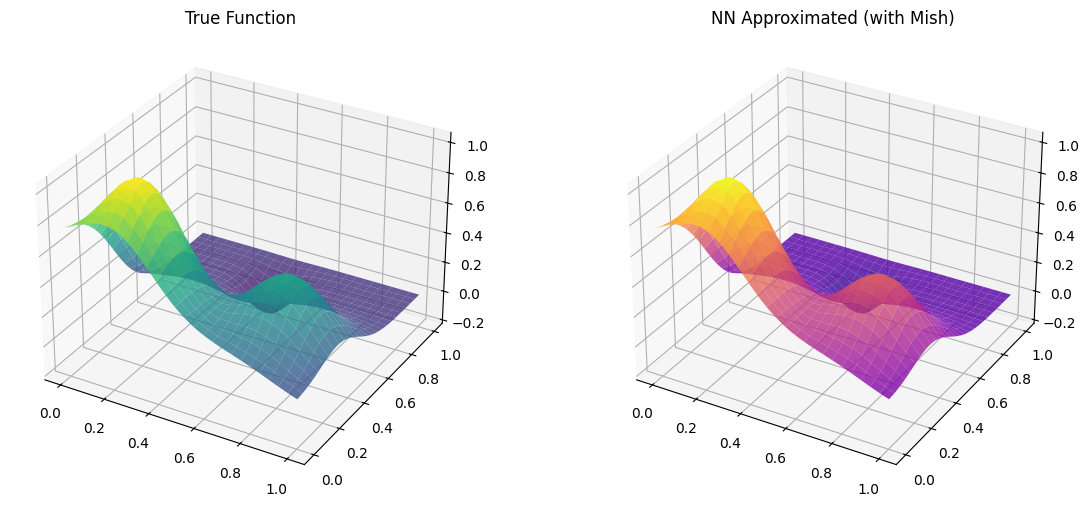

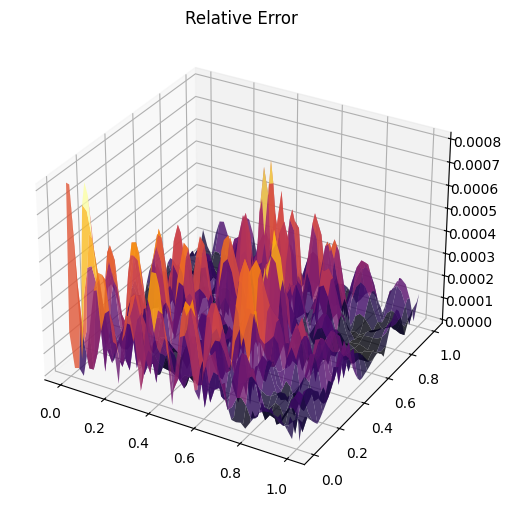

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義（ベース共通化）
def franke_base(x, y, xp):
    term1 = 0.75 * xp.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * xp.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * xp.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * xp.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

def franke_function(x, y):
    return franke_base(x, y, np)

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)

# 【変更点】入力に requires_grad=True を指定し、ラベルは torch の数式でグラフを繋げて計算
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32, requires_grad=True)
labels = franke_base(features[:, 0], features[:, 1], torch).view(-1, 1)

# 【追加】真の勾配を計算し、.detach() で定数化（計算グラフを切り離す）
true_grad = torch.autograd.grad(
    outputs=labels, inputs=features, grad_outputs=torch.ones_like(labels), create_graph=False
)[0].detach()

# ラベル自体も定数化
labels = labels.detach()

# 3. モデル定義 (指定の silu 4層モデル)
class Mish_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Mish(),
            nn.Linear(64, 64),
            nn.Mish(),
            nn.Linear(64, 64),
            nn.Mish(),
            nn.Linear(64, 64),
            nn.Mish(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = Mish_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
lambda_grad = 0.1  # 勾配正則化の係数

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss_val = criterion(pred, labels)
    
    # 【追加】予測値の勾配計算
    pred_grad = torch.autograd.grad(
        outputs=pred, inputs=features, grad_outputs=torch.ones_like(pred), create_graph=True
    )[0]
    loss_grad = criterion(pred_grad, true_grad)
    
    # 合計損失
    total_loss = loss_val + lambda_grad * loss_grad
    total_loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(total_loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Total Loss {total_loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Mish)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

有理関数活性化関数(2次の簡易版)

学習を開始します...
Epoch 500: Total Loss 2.614383e-04 | LR 0.005000
Epoch 1000: Total Loss 2.975504e-05 | LR 0.005000
Epoch 1500: Total Loss 2.318004e-05 | LR 0.005000
Epoch 2000: Total Loss 1.429169e-05 | LR 0.001250
Epoch 2500: Total Loss 1.121080e-05 | LR 0.001250
Epoch 3000: Total Loss 8.698074e-06 | LR 0.001250
Epoch 3500: Total Loss 6.625701e-06 | LR 0.001250
Epoch 4000: Total Loss 4.949435e-06 | LR 0.001250
Epoch 4500: Total Loss 4.144828e-06 | LR 0.001250
Epoch 5000: Total Loss 3.182114e-06 | LR 0.001250
訓練が完了しました。
Max Relative Error: 0.000846


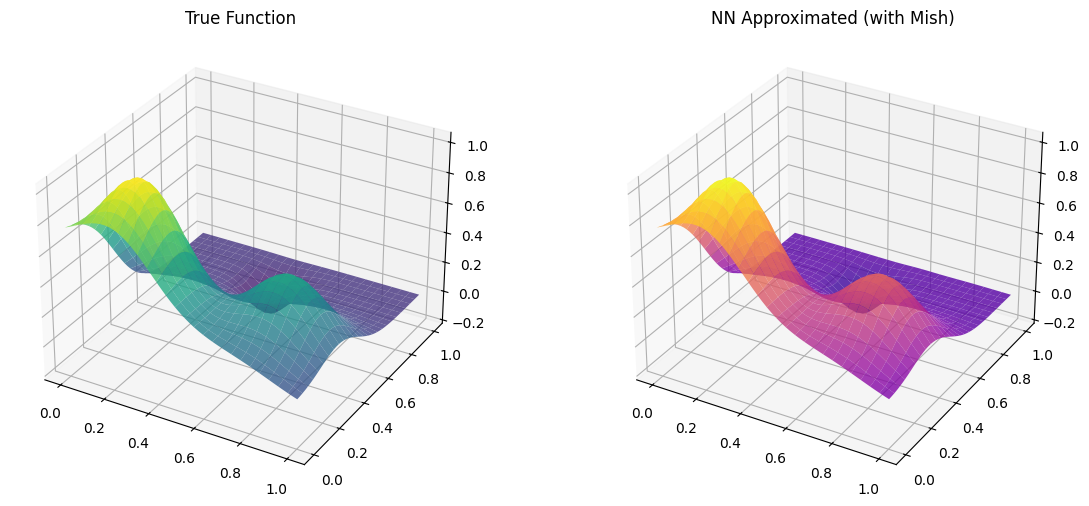

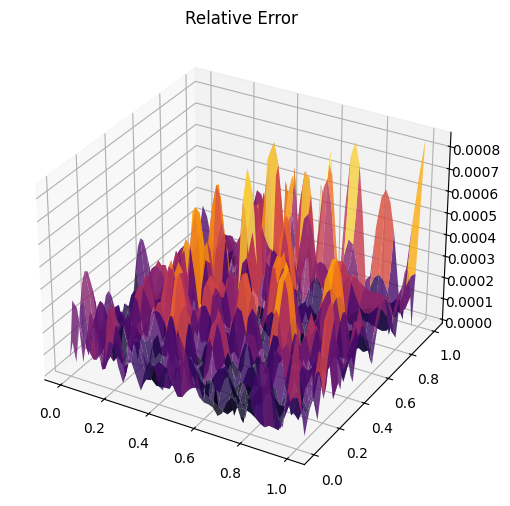

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)

# 【変更点】入力に requires_grad=True を指定し、ラベルは torch の数式でグラフを繋げて計算
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32, requires_grad=True)
labels = franke_base(features[:, 0], features[:, 1], torch).view(-1, 1)

# 【追加】真の勾配を計算し、.detach() で定数化（計算グラフを切り離す）
true_grad = torch.autograd.grad(
    outputs=labels, inputs=features, grad_outputs=torch.ones_like(labels), create_graph=False
)[0].detach()

# ラベル自体も定数化
labels = labels.detach()

class RationalActivation(nn.Module):
    def __init__(self):
        super().__init__()
        # Padé近似形式の係数を学習可能パラメータとして定義
        # 初期値は ReLU に近い挙動をするよう調整
        self.a = nn.Parameter(torch.tensor([0.0, 1.0, 0.0])) # 分子: a0 + a1*x + a2*x^2
        self.b = nn.Parameter(torch.tensor([0.0, 0.0, 0.1])) # 分母: 1 + b1*x + b2*x^2
        
    def forward(self, x):
        numerator = self.a[0] + self.a[1] * x + self.a[2] * x**2
        denominator = 1.0 + self.b[1] * x + self.b[2] * x**2
        return numerator / (denominator + 1e-6) # ゼロ除算防止

# 3. モデル定義 (Rational Activation を使用)
class Rational_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # 幅を64に縮小
            RationalActivation(),         # 活性化関数
            nn.Linear(64, 64), # 中間層1
            RationalActivation(),
            nn.Linear(64, 64), # 中間層2
            RationalActivation(),
            nn.Linear(64, 64), # 中間層3
            RationalActivation(),
            nn.Linear(64, 1)   # 出力層
        )
    def forward(self, x):
        return self.net(x)


model = Rational_MLP()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
lambda_grad = 0.1  # 勾配正則化の係数

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss_val = criterion(pred, labels)
    
    # 【追加】予測値の勾配計算
    pred_grad = torch.autograd.grad(
        outputs=pred, inputs=features, grad_outputs=torch.ones_like(pred), create_graph=True
    )[0]
    loss_grad = criterion(pred_grad, true_grad)
    
    # 合計損失
    total_loss = loss_val + lambda_grad * loss_grad
    total_loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(total_loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Total Loss {total_loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Mish)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()